In [1]:
import sys

sys.path.append("..")

import matplotlib.pyplot as plt
from src.features.data_preprocessing import load_data, drop_duplicates
from src.features.build_features import cleaned_review, encode_sentiment
from src.features.split_data import split_data, split_features_and_target
from src.features.text_preprocessing import vectorizer
from src.model.train import TrainModel

In [2]:
df = load_data("../data/raw/IMDB Dataset.csv")
df.head()

Data loaded successfully from (../data/raw/IMDB Dataset.csv)


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [3]:
df.shape

(50000, 2)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [5]:
df["sentiment"].value_counts()

sentiment
positive    25000
negative    25000
Name: count, dtype: int64

In [6]:
df.isnull().sum()

review       0
sentiment    0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(418)

In [8]:
duplicated_rows =df[df.duplicated(keep=False)]
duplicated_rows.head(20)

,review,sentiment
42,"Of all the films I have seen, this one, The Ra...",negative
84,"We brought this film as a joke for a friend, a...",negative
140,"Before I begin, let me get something off my ch...",negative
219,Ed Wood rides again. The fact that this movie ...,negative
245,I have seen this film at least 100 times and I...,positive
480,From director Barbet Schroder (Reversal of For...,negative
513,"The story and the show were good, but it was r...",negative
636,I rented this thinking it would be pretty good...,negative
638,This movie has everything typical horror movie...,positive
701,I Enjoyed Watching This Well Acted Movie Very ...,positive


In [9]:
# Check if the duplicated rows are identical

df[
    (df['review'] == df.loc[42, 'review']) &
    (df['sentiment'] == df.loc[42, 'sentiment'])
]

,review,sentiment
42,"Of all the films I have seen, this one, The Ra...",negative
25088,"Of all the films I have seen, this one, The Ra...",negative


In [10]:
df = drop_duplicates(df)

Dropped 418 duplicated rows.


In [11]:
df.describe()

,review,sentiment
count,49582,49582
unique,49582,2
top,No one expects the Star Trek movies to be high...,positive
freq,1,24884


Text(0, 0.5, 'Count')

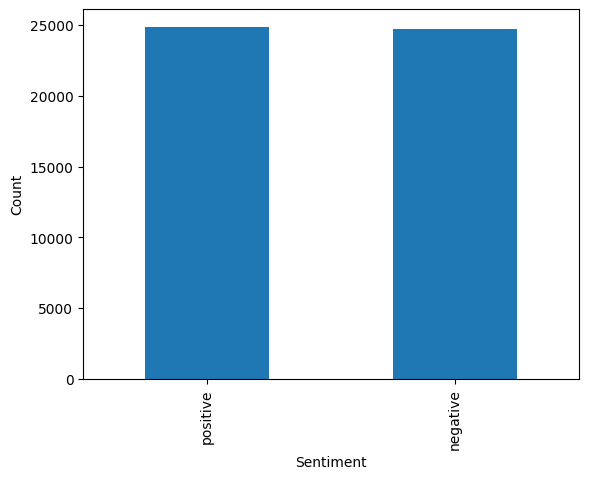

In [12]:
df["sentiment"].value_counts().plot(kind='bar')

df.title = "Distribution of Sentiment Labels"
plt.xlabel("Sentiment")
plt.ylabel("Count")

In [13]:
df = cleaned_review(df)

df[["review", "cleaned_review"]].head()

Added 'cleaned_review' column to the DataFrame.


,review,cleaned_review
0,One of the other reviewers has mentioned that ...,one reviewer mentioned watching oz episode you...
1,A wonderful little production. <br /><br />The...,wonderful little production filming technique ...
2,I thought this was a wonderful way to spend ti...,thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,basically there family little boy jake think t...
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter matteis love time money visually stunni...


In [14]:
# Display original and cleaned reviews side by side for the first 5 entries

for i in range(5):
    print("ORIGINAL:")
    print(df["review"].iloc[i])

    print("\nCLEANED:")
    print(df["cleaned_review"].iloc[i])

    print("-" * 100)

ORIGINAL:
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due 

In [15]:
df = encode_sentiment(df)
df.head()

Encoded 'sentiment' column to 'encoded_sentiment' with values 1 for positive and 0 for negative.


,review,sentiment,cleaned_review,encoded_sentiment
0,One of the other reviewers has mentioned that ...,positive,one reviewer mentioned watching oz episode you...,1
1,A wonderful little production. <br /><br />The...,positive,wonderful little production filming technique ...,1
2,I thought this was a wonderful way to spend ti...,positive,thought wonderful way spend time hot summer we...,1
3,Basically there's a family where a little boy ...,negative,basically there family little boy jake think t...,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,petter matteis love time money visually stunni...,1


In [16]:
train_df, val_df, test_df = split_data(df)

Training set size: 34707 samples
Validation set size: 7437 samples
Testing set size: 7438 samples


In [17]:
X_train, y_train = split_features_and_target(train_df)
X_val, y_val = split_features_and_target(val_df)
X_test, y_test = split_features_and_target(test_df)

In [18]:
X_train.shape

(34707,)

In [19]:
y_train.head()

8980     0
35912    0
47554    0
10799    1
38610    0
Name: encoded_sentiment, dtype: int64

In [20]:
X_train_tfidf = vectorizer.fit_transform(X_train)
X_val_tfidf = vectorizer.transform(X_val)

In [21]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train_tfidf, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [22]:
model_score = model.score(X_train_tfidf, y_train)
model_score

0.9122943498429712

In [23]:
from sklearn.metrics import classification_report, confusion_matrix


y_pred = model.predict(X_val_tfidf)

print(classification_report(y_val, y_pred))


              precision    recall  f1-score   support

           0       0.90      0.88      0.89      3728
           1       0.88      0.90      0.89      3709

    accuracy                           0.89      7437
   macro avg       0.89      0.89      0.89      7437
weighted avg       0.89      0.89      0.89      7437



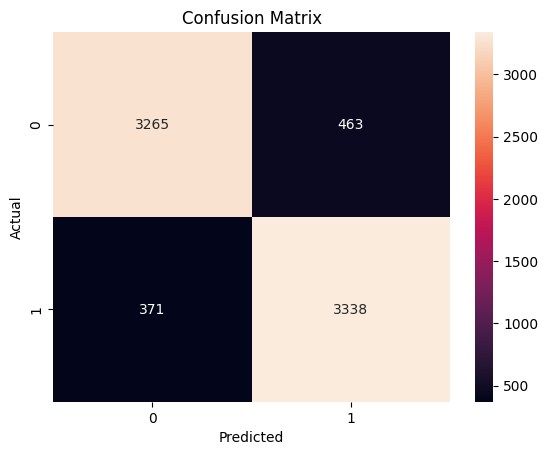

In [24]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_val, y_pred)

sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [25]:
trainer = TrainModel()

Pipeline built successfully with text preprocessing, TF-IDF vectorization, and logistic regression classifier.


In [26]:
trainer.fit(X_train, y_train)

,steps,"[('preprocess_text', ...), ('tfidf_vectorizer', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,func,<function pre...001E6F6A03250>
,inverse_func,None
,validate,False
,accept_sparse,False
,check_inverse,True
,feature_names_out,None
,kw_args,None


In [27]:
trainer.predict(X_val)

array([0, 0, 0, ..., 1, 1, 1], shape=(7437,))

In [28]:
trainer.evaluate(X_val, y_val, X_train, y_train)

{'train_score': 0.9100757772207335,
 'accuracy': 0.8855721393034826,
 'precision': 0.8858647113390669,
 'recall': 0.8855721393034826,
 'f1': 0.8855550027199264,
 'roc_auc': 0.9530120157788097}